Fitting 5 folds for each of 1 candidates, totalling 5 fits

=== Best XGBoost Model ===
Best F1 Score: 0.6746666666666667
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 50, 'classifier__reg_alpha': 0.1, 'classifier__reg_lambda': 1, 'classifier__subsample': 1.0}

=== Evaluation on Test Dataset ===
Accuracy: 0.6333333333333333
Classification Report:
              precision    recall  f1-score   support

        crop       0.64      0.60      0.62        15
        wild       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30



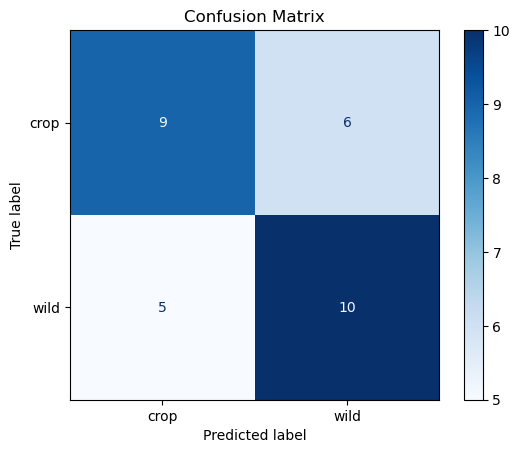

C:\Users\User\anaconda3\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


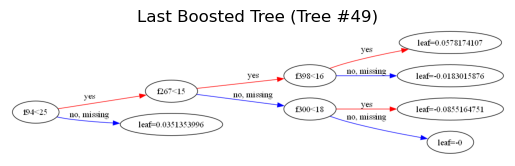

<Figure size 800x600 with 0 Axes>

In [3]:
# Single Fit

# === Setup ===
!pip install xgboost pandas scikit-learn matplotlib

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier, plot_tree

# === Parameters ===
CSV_FILE = "virus_data.csv"  # CSV with id, type, family, length, sequence
KMER_SIZE = 4
RANDOM_STATE = 42
N_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load CSV Data ===
def load_data(csv_path, k):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACGT]', '', regex=True)
    df['kmers'] = df['sequence'].apply(lambda seq: get_kmers(seq, k))
    df = df[df['kmers'].str.len() > 0].copy()

    return df['kmers'], df['type'], df['id']

# === XGBoost Pipeline with Extended Grid ===
def run_xgboost_pipeline(kmers_train, y_train):
    pipeline = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ("classifier", XGBClassifier(
            use_label_encoder=False, 
            eval_metric='mlogloss', 
            random_state=RANDOM_STATE
        ))
    ])

    # Expanded parameter grid for HPCC scale
    param_grid = {
        "classifier__n_estimators": [100]
        "classifier__max_depth": [3]
        "classifier__learning_rate": [0.01]
        "classifier__subsample": [0.6]
        "classifier__colsample_bytree": [0.6]
        "classifier__reg_alpha": [0]
        "classifier__reg_lambda": [1]
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2
    )
    grid.fit(kmers_train, y_train)

    print("\n=== Best XGBoost Model ===")
    print("Best F1 Score:", grid.best_score_)
    print("Best Parameters:", grid.best_params_)

    return grid.best_estimator_

# === Evaluation ===
def evaluate_model(model, kmers_test, y_test, le):
    y_pred = model.predict(kmers_test)
    print("\n=== Evaluation on Test Dataset ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # === Tree Visualization ===
    xgb_model = model.named_steps['classifier']
    n_trees = xgb_model.get_booster().num_boosted_rounds()

    # Plot last tree
    plt.figure(figsize=(12, 6))
    plot_tree(xgb_model, num_trees=n_trees - 1, rankdir='LR')
    plt.title(f"Last Boosted Tree (Tree #{n_trees - 1})")
    plt.show()

# === Main Pipeline ===
def main():
    kmers, labels, seq_ids = load_data(CSV_FILE, k=KMER_SIZE)

    le = LabelEncoder()
    y = le.fit_transform(labels)

    kmers_train, kmers_test, y_train, y_test = train_test_split(
        kmers, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    best_model = run_xgboost_pipeline(kmers_train, y_train)
    evaluate_model(best_model, kmers_test, y_test, le)

main()


In [ ]:
# Hyperparameter Tuning

# === Setup ===
!pip install xgboost pandas scikit-learn matplotlib

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier, plot_tree

# === Parameters ===
CSV_FILE = "virus_data.csv"  # CSV with id, type, family, length, sequence
KMER_SIZE = 4
RANDOM_STATE = 42
N_SPLITS = 5

# === K-mer Extraction ===
def get_kmers(sequence, k):
    sequence = sequence.upper()
    return ' '.join([sequence[i:i+k] for i in range(len(sequence) - k + 1)]) if len(sequence) >= k else ''

# === Load CSV Data ===
def load_data(csv_path, k):
    df = pd.read_csv(csv_path)
    df['sequence'] = df['sequence'].str.upper().str.replace(r'[^ACGT]', '', regex=True)
    df['kmers'] = df['sequence'].apply(lambda seq: get_kmers(seq, k))
    df = df[df['kmers'].str.len() > 0].copy()

    return df['kmers'], df['type'], df['id']

# === XGBoost Pipeline with Extended Grid ===
def run_xgboost_pipeline(kmers_train, y_train):
    pipeline = Pipeline([
        ("vectorizer", CountVectorizer()),
        ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ("classifier", XGBClassifier(
            use_label_encoder=False, 
            eval_metric='mlogloss', 
            random_state=RANDOM_STATE
        ))
    ])

    # Expanded parameter grid for HPCC scale
    param_grid = {
        "classifier__n_estimators": [100, 200, 500],
        "classifier__max_depth": [3, 5, 10, 15],
        "classifier__learning_rate": [0.01, 0.1, 0.2],
        "classifier__subsample": [0.6, 0.8, 1.0],
        "classifier__colsample_bytree": [0.6, 0.8, 1.0],
        "classifier__reg_alpha": [0, 0.1, 1],
        "classifier__reg_lambda": [1, 5, 10]
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=2
    )
    grid.fit(kmers_train, y_train)

    print("\n=== Best XGBoost Model ===")
    print("Best F1 Score:", grid.best_score_)
    print("Best Parameters:", grid.best_params_)

    return grid.best_estimator_

# === Evaluation ===
def evaluate_model(model, kmers_test, y_test, le):
    y_pred = model.predict(kmers_test)
    print("\n=== Evaluation on Test Dataset ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # === Tree Visualization ===
    xgb_model = model.named_steps['classifier']
    n_trees = xgb_model.get_booster().num_boosted_rounds()

    # Plot last tree
    plt.figure(figsize=(12, 6))
    plot_tree(xgb_model, num_trees=n_trees - 1, rankdir='LR')
    plt.title(f"Last Boosted Tree (Tree #{n_trees - 1})")
    plt.show()

# === Main Pipeline ===
def main():
    kmers, labels, seq_ids = load_data(CSV_FILE, k=KMER_SIZE)

    le = LabelEncoder()
    y = le.fit_transform(labels)

    kmers_train, kmers_test, y_train, y_test = train_test_split(
        kmers, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    best_model = run_xgboost_pipeline(kmers_train, y_train)
    evaluate_model(best_model, kmers_test, y_test, le)

main()
